# 1. Καθαρισμός Δεδομένων και Διερευνητική Ανάλυση  
## (Data Cleaning & Exploratory Data Analysis)

Το παρόν notebook παρουσιάζει το στάδιο του **Data Cleaning** και της **Exploratory Data Analysis (EDA)** για τη μελέτη της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική για την περίοδο 2021–2026.

Η ανάλυση βασίζεται στο καθαρισμένο dataset που έχει παραχθεί μέσω του script `src/data_cleaning.py` και αποθηκεύεται στον φάκελο `data/processed/`.

Σκοπός του notebook είναι:
- να παρουσιαστεί η τελική μορφή του dataset,
- να εξεταστεί η ποιότητα των δεδομένων,
- να αναλυθούν οι βασικές κατανομές και σχέσεις των μεταβλητών,
- και να εξαχθούν τα πρώτα ερευνητικά ευρήματα που θα υποστηρίξουν το στάδιο της **price prediction**.

## Μεθοδολογικό Πλαίσιο (Methodological Framework)

Η ροή της ανάλυσης ακολουθεί τα εξής στάδια:

1. **Raw data ingestion** από το αρχικό αρχείο Excel.
2. **Data cleaning & preprocessing** μέσω του script `src/data_cleaning.py`.
3. **Loading του cleaned dataset** στο παρόν notebook.
4. **Exploratory Data Analysis (EDA)** με descriptive statistics και visualizations.
5. Προετοιμασία για το επόμενο στάδιο της **predictive modeling**.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Βασικές ρυθμίσεις για καθαρότερη παρουσίαση
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Φόρτωση Καθαρισμένου Dataset

Σε αυτό το σημείο φορτώνεται το τελικό καθαρισμένο dataset από τον φάκελο `data/processed/`.

Το αρχείο αυτό αποτελεί τη βάση για όλη την παρούσα διερευνητική ανάλυση και είναι αποτέλεσμα του εξωτερικού cleaning pipeline που υλοποιείται στο `src/data_cleaning.py`.

In [4]:
def find_project_root(start_path: Path) -> Path:
    """
    Εντοπισμός του root φακέλου του project ανεβαίνοντας προς τα πάνω
    μέχρι να βρεθούν οι βασικοί φάκελοι data και src.
    """
    current = start_path.resolve()

    for path in [current] + list(current.parents):
        if (path / "data").exists() and (path / "src").exists():
            return path

    raise FileNotFoundError("Δεν βρέθηκε ο root φάκελος του project.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_car_data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Το αρχείο δεν βρέθηκε: {DATA_PATH}\n"
        "Τρέξε πρώτα: python src\\data_cleaning.py"
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.head()

,Α/Α,Κατασκευαστής,Τύπος,Εγγραφή,Κυβικά,Ιπποδύναμη,Καύσιμο,Μετάδοση,Χιλιόμετρα,Τιμή,Κατάσταση,Περιγραφή,Περιοχή,Διεύθυνση,Σειρά Scraping,Ιστοσελίδα,Φωτογραφία 1,Φωτογραφία 2,Φωτογραφία 3,Ηλικία
0,1,Audi,Q3,"2,025.00","1,500.00",150.00,Βενζίνη,Αυτόματο,"10,500.00","34,900.00",Μεταχειρισμένο,Q3 Advanced Plus 35 TFSI 150 hp S tronic,ΚΗΦΙΣΙΑ 14561,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14561,1769681066-1,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51909142_i_n.jpg,NaN,NaN,1.00
1,2,Toyota,Yaris Cross,"2,025.00","1,500.00",116.00,Υβριδικό Βενζίνης,Αυτόματο,"10,018.00","25,990.00",Μεταχειρισμένο,1.5-116ps-style!!,ΝΕΑ ΙΩΝΙΑ 14235,ΝΕΑ ΙΩΝΙΑ Ν. ΑΤΤΙΚΗΣ 14235,1769681066-2,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51329883_0_n.jpg,NaN,NaN,1.00
2,3,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"3,000.00","26,500.00",Μεταχειρισμένο,"Hybrid Allure - ΕΡΓΟΣΤΑΣΙΑΚΗ ΕΓΓΥΗΣΗ 5 ΕΤΗ, 30...",ΚΗΦΙΣΙΑ 14562,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14562,1769681066-3,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51432222_0_n.jpg,NaN,NaN,1.00
3,4,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"2,900.00","26,500.00",Μεταχειρισμένο,2008 Allure Hybrid Εργ. Εγγύηση 5 έτη - Μόνο 3...,ΝΕΑ ΕΡΥΘΡΑΙA 14671,ΝΕΑ ΕΡΥΘΡΑΙA Ν. ΑΤΤΙΚΗΣ 14671 ΝΕΑ ΕΡΥΘΡΑΙΑ,1769681066-4,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51689355_0_n.jpg,NaN,NaN,1.00
4,5,Beev,ΒEEV-6,"2,025.00",NaN,4.00,Ηλεκτρικό,Αυτόματο,0.00,"10,900.00",Καινούργιο,ΒEEV-6 4P,ΓΛΥΚΑ ΝΕΡΑ 15354,ΓΛΥΚΑ ΝΕΡΑ Ν. ΑΤΤΙΚΗΣ 15354,1769681066-5,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/48676062_b_n.jpg,NaN,NaN,1.00


## Πρώτη Επισκόπηση του Dataset

Αρχικά εξετάζονται:
- οι διαστάσεις του dataset,
- τα ονόματα των στηλών,
- οι τύποι δεδομένων (*data types*),
- και ένα πρώτο δείγμα εγγραφών.

Η αρχική αυτή επισκόπηση είναι κρίσιμη ώστε να επιβεβαιωθεί ότι το dataset έχει φορτωθεί σωστά και ότι η δομή του είναι συμβατή με τη συνέχεια της ανάλυσης.

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (8933, 20)

Columns:
['Α/Α', 'Κατασκευαστής', 'Τύπος', 'Εγγραφή', 'Κυβικά', 'Ιπποδύναμη', 'Καύσιμο', 'Μετάδοση', 'Χιλιόμετρα', 'Τιμή', 'Κατάσταση', 'Περιγραφή', 'Περιοχή', 'Διεύθυνση', 'Σειρά Scraping', 'Ιστοσελίδα', 'Φωτογραφία 1', 'Φωτογραφία 2', 'Φωτογραφία 3', 'Ηλικία']


In [6]:
# Επισκόπηση τύπων δεδομένων
df.dtypes

Α/Α                 int64
Κατασκευαστής         str
Τύπος                 str
Εγγραφή           float64
Κυβικά            float64
Ιπποδύναμη        float64
Καύσιμο               str
Μετάδοση              str
Χιλιόμετρα        float64
Τιμή              float64
Κατάσταση             str
Περιγραφή             str
Περιοχή               str
Διεύθυνση             str
Σειρά Scraping        str
Ιστοσελίδα            str
Φωτογραφία 1          str
Φωτογραφία 2          str
Φωτογραφία 3          str
Ηλικία            float64
dtype: object

In [7]:
# Τυχαίο δείγμα εγγραφών για γρήγορη ποιοτική επιθεώρηση
df.sample(5, random_state=42)

,Α/Α,Κατασκευαστής,Τύπος,Εγγραφή,Κυβικά,Ιπποδύναμη,Καύσιμο,Μετάδοση,Χιλιόμετρα,Τιμή,Κατάσταση,Περιγραφή,Περιοχή,Διεύθυνση,Σειρά Scraping,Ιστοσελίδα,Φωτογραφία 1,Φωτογραφία 2,Φωτογραφία 3,Ηλικία
315,316,Peugeot,2008,"2,025.00","1,200.00",100.00,Βενζίνη,Χειροκίνητο,"10,926.00","19,100.00",Μεταχειρισμένο,Style 4 ΕΤΗ ΕΡΓΟΣΤΑΣΙΑΚΗ ΕΓΓΥΗΣΗ * GALLO S.A. *,ΝΕΑ ΧΑΛΚΗΔΟΝΑ 14343,ΝΕΑ ΧΑΛΚΗΔΟΝΑ Ν. ΑΤΤΙΚΗΣ 14343,1769681066-328,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51495205_eLi_n.jpg,NaN,NaN,1.00
3395,3396,Alfa Romeo,Tonale,"2,024.00","1,300.00",280.00,Plug-in Hybrid Βενζίνης,Αυτόματο,"9,760.00","38,980.00",Μεταχειρισμένο,SPRINT PHEV,ΜΑΡΟΥΣΙ 15124,ΜΑΡΟΥΣΙ Ν. ΑΤΤΙΚΗΣ 15124,1769681066-3622,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/50282774_iBx_n.jpg,https://static.car.gr/50282774_iBx_n.jpg,NaN,2.00
623,624,Mini,Countryman,"2,025.00","1,500.00",170.00,Βενζίνη,Αυτόματο,0.00,"43,500.00",Καινούργιο,(Countryman C),ΝΕΑ ΣΜΥΡΝΗ 17122,ΝΕΑ ΣΜΥΡΝΗ Ν. ΑΤΤΙΚΗΣ 17122,1769681066-654,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/48868135_fNC_n.jpg,NaN,NaN,1.00
1183,1184,Porsche,Macan,"2,025.00",NaN,360.00,Ηλεκτρικό,Αυτόματο,"6,000.00","92,850.00",Μεταχειρισμένο,Ηλεκτρικη Bosganas,ΑΘΗΝΑ 11636,ΑΘΗΝΑ 11636,1769681066-1276,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/45822361_0_n.jpg,NaN,NaN,1.00
5829,5830,BMW,118,"2,022.00","1,500.00",136.00,Βενζίνη,Αυτόματο,"78,280.00","21,980.00",Μεταχειρισμένο,5 Χρόνια Εγγύηση - 118i ADVANCE,ΓΕΡΑΚΑΣ 15344,ΓΕΡΑΚΑΣ Ν. ΑΤΤΙΚΗΣ 15344,1769681066-6099,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/48961609_8li_n.jpg,https://static.car.gr/48961609_8li_n.jpg,NaN,4.00


In [8]:
# Συνοπτικός πίνακας μεταβλητών
column_overview = pd.DataFrame({
    "column_name": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes.values],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2)
})

column_overview

,column_name,dtype,missing_count,missing_pct
0,Α/Α,int64,0,0.00
1,Κατασκευαστής,str,0,0.00
2,Τύπος,str,0,0.00
3,Εγγραφή,float64,0,0.00
4,Κυβικά,float64,769,8.61
5,Ιπποδύναμη,float64,0,0.00
6,Καύσιμο,str,0,0.00
7,Μετάδοση,str,0,0.00
8,Χιλιόμετρα,float64,2,0.02
9,Τιμή,float64,0,0.00


## Έλεγχος Ποιότητας Δεδομένων (Data Quality Check)

Στο στάδιο αυτό εξετάζονται:
- οι ελλείπουσες τιμές (*missing values*),
- τα διπλότυπα (*duplicates*),
- και η συνολική πληρότητα του dataset.

Ο έλεγχος αυτός είναι απαραίτητος ώστε η ανάλυση να βασίζεται σε αξιόπιστα και συνεπή δεδομένα.

In [9]:
# Πίνακας missing values
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_table

,missing_count,missing_pct
Φωτογραφία 3,8711,97.51
Φωτογραφία 2,1306,14.62
Κυβικά,769,8.61
Περιγραφή,493,5.52
Χιλιόμετρα,2,0.02
Τύπος,0,0.00
Κατασκευαστής,0,0.00
Α/Α,0,0.00
Εγγραφή,0,0.00
Καύσιμο,0,0.00


In [10]:
# Έλεγχος exact duplicates
print("Συνολικός αριθμός exact duplicate rows:", df.duplicated().sum())

Συνολικός αριθμός exact duplicate rows: 0


### Σχόλιο επί της ποιότητας των δεδομένων

Με βάση τον παραπάνω έλεγχο, το dataset εμφανίζει υψηλό βαθμό πληρότητας στις βασικές μεταβλητές που σχετίζονται με την ανάλυση τιμών, όπως η `Τιμή`, τα `Χιλιόμετρα`, η `Ιπποδύναμη`, το `Καύσιμο` και η `Μετάδοση`.

Οι ελλείπουσες τιμές εντοπίζονται κυρίως σε δευτερεύουσες μεταβλητές, όπως η `Περιγραφή` ή ορισμένα πεδία φωτογραφιών, ενώ δεν παρατηρούνται **exact duplicate rows**.

Συνεπώς, το dataset μπορεί να θεωρηθεί κατάλληλο για **descriptive analysis** και για το επόμενο στάδιο της **predictive modeling**.

## Περιγραφική Στατιστική (Descriptive Statistics)

Στην ενότητα αυτή εξετάζονται οι βασικές αριθμητικές μεταβλητές του dataset, όπως:
- η τιμή πώλησης,
- τα χιλιόμετρα,
- η ιπποδύναμη,
- τα κυβικά,
- και η ηλικία του οχήματος.

Η περιγραφική στατιστική παρέχει μία πρώτη συνολική εικόνα της δομής της αγοράς μεταχειρισμένων αυτοκινήτων.

In [11]:
# Επιλογή αριθμητικών μεταβλητών για descriptive statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Α/Α,"8,933.00","4,467.00","2,578.88",1.00,"2,234.00","4,467.00","6,700.00","8,933.00"
Εγγραφή,"8,933.00","2,022.46",1.48,"2,021.00","2,021.00","2,022.00","2,023.00","2,026.00"
Κυβικά,"8,164.00","1,573.78",593.40,600.00,"1,200.00","1,500.00","1,700.00","6,400.00"
Ιπποδύναμη,"8,933.00",180.22,118.55,3.00,109.00,131.00,218.00,"1,139.00"
Χιλιόμετρα,"8,931.00","51,910.51","41,548.99",0.00,"17,500.00","46,600.00","76,000.00","370,000.00"
Τιμή,"8,933.00","33,640.77","34,133.22","2,000.00","16,900.00","22,700.00","35,900.00","550,000.00"
Ηλικία,"8,933.00",3.54,1.48,0.00,3.00,4.00,5.00,5.00


## Κατανομή της Τιμής Πώλησης (Price Distribution)

Η μεταβλητή `Τιμή` αποτελεί τη **target variable** της μελέτης.  
Η εξέταση της κατανομής της επιτρέπει:
- την κατανόηση της συνολικής διασποράς των τιμών,
- τον εντοπισμό πιθανής ασυμμετρίας (*skewness*),
- και την αναγνώριση ακραίων τιμών (*outliers*).

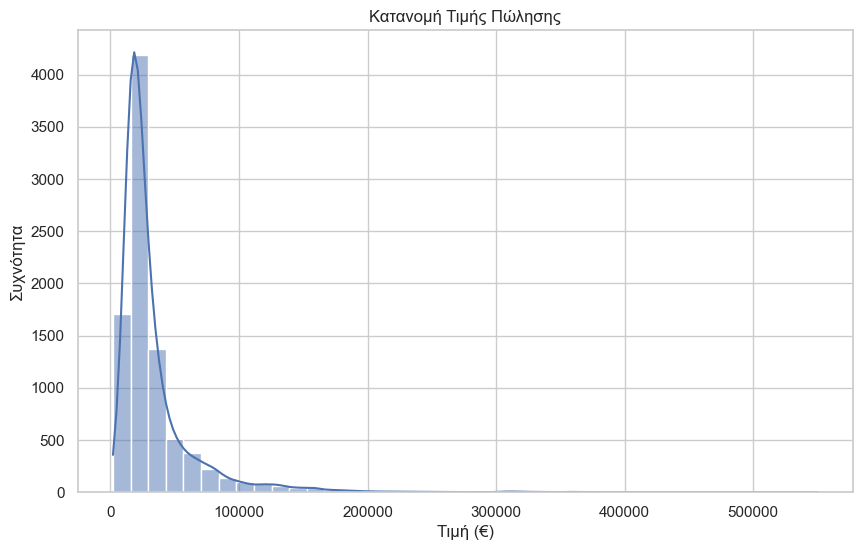

In [12]:
# Histogram της τιμής πώλησης
plt.figure(figsize=(10, 6))
sns.histplot(df["Τιμή"].dropna(), bins=40, kde=True)
plt.title("Κατανομή Τιμής Πώλησης")
plt.xlabel("Τιμή (€)")
plt.ylabel("Συχνότητα")
plt.show()

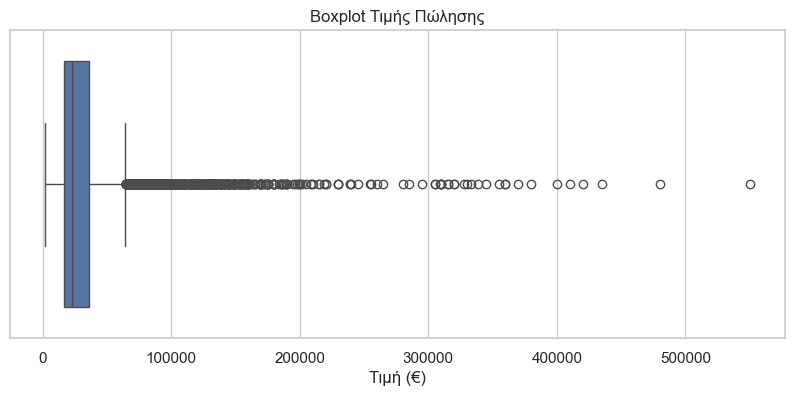

In [13]:
# Boxplot για γρήγορη οπτική αναγνώριση outliers στην τιμή
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Τιμή"])
plt.title("Boxplot Τιμής Πώλησης")
plt.xlabel("Τιμή (€)")
plt.show()

## Κατανομή των Χιλιομέτρων (Mileage Distribution)

Τα χιλιόμετρα αποτελούν βασική μεταβλητή χρήσης του οχήματος και αναμένεται να σχετίζονται αρνητικά με την τιμή πώλησης.

Η ανάλυση της κατανομής τους βοηθά στον εντοπισμό:
- συχνότερων επιπέδων χρήσης,
- ακραίων παρατηρήσεων,
- και πιθανών ασυμμετριών στην αγορά.

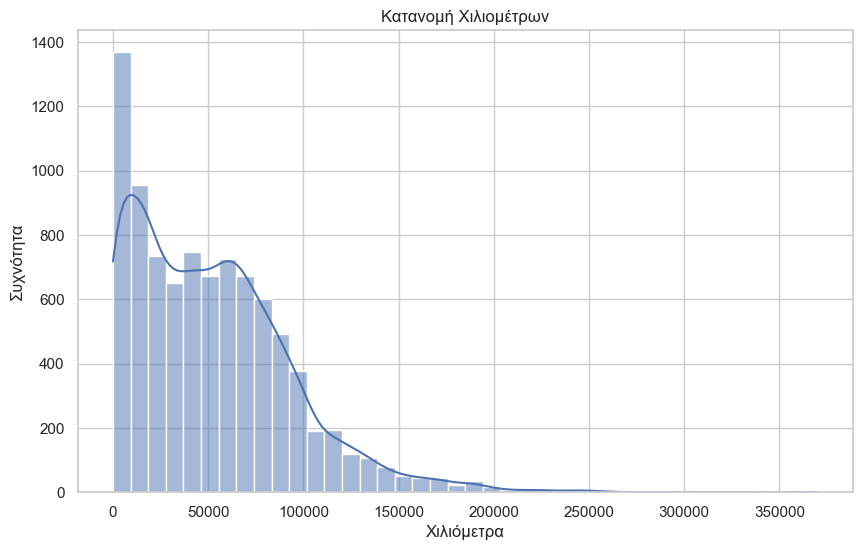

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Χιλιόμετρα"].dropna(), bins=40, kde=True)
plt.title("Κατανομή Χιλιομέτρων")
plt.xlabel("Χιλιόμετρα")
plt.ylabel("Συχνότητα")
plt.show()

## Κατανομή Βασικών Τεχνικών Χαρακτηριστικών

Σε αυτό το σημείο εξετάζονται μεταβλητές που περιγράφουν τα τεχνικά χαρακτηριστικά των οχημάτων:
- `Ηλικία`,
- `Ιπποδύναμη`,
- `Κυβικά`.

Οι μεταβλητές αυτές θεωρούνται ιδιαίτερα σημαντικές για την ερμηνεία της μεταβολής της τιμής πώλησης.

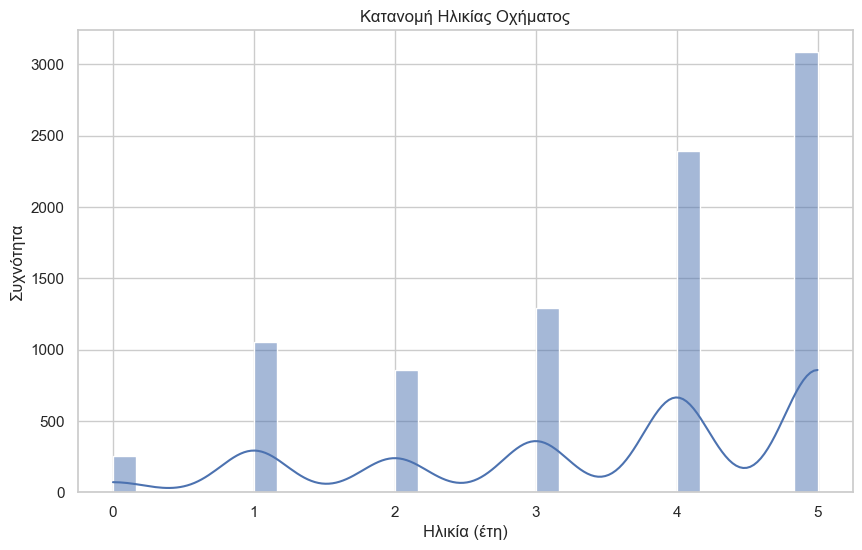

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Ηλικία"].dropna(), bins=30, kde=True)
plt.title("Κατανομή Ηλικίας Οχήματος")
plt.xlabel("Ηλικία (έτη)")
plt.ylabel("Συχνότητα")
plt.show()

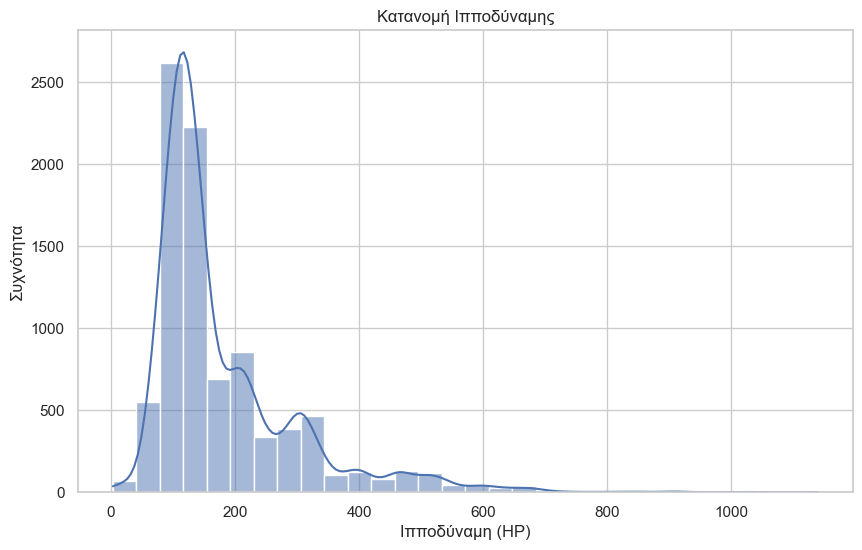

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Ιπποδύναμη"].dropna(), bins=30, kde=True)
plt.title("Κατανομή Ιπποδύναμης")
plt.xlabel("Ιπποδύναμη (HP)")
plt.ylabel("Συχνότητα")
plt.show()

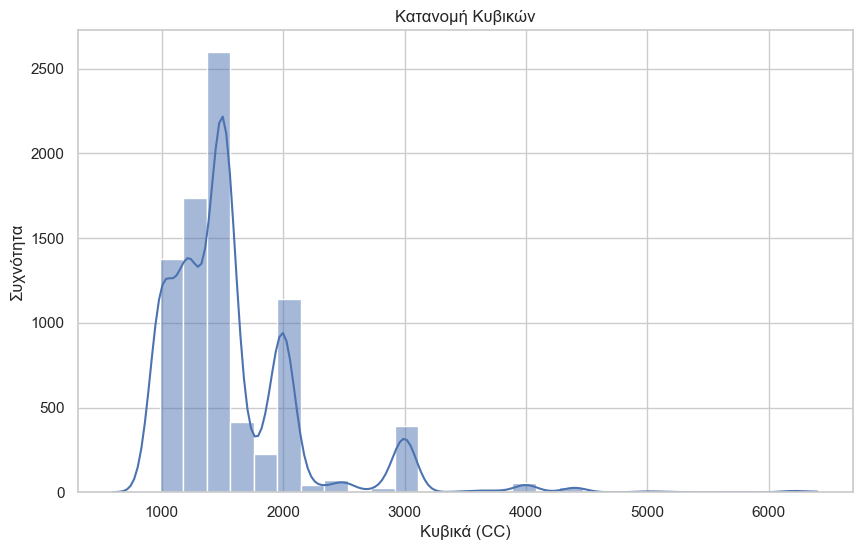

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Κυβικά"].dropna(), bins=30, kde=True)
plt.title("Κατανομή Κυβικών")
plt.xlabel("Κυβικά (CC)")
plt.ylabel("Συχνότητα")
plt.show()

## Ανάλυση Κατηγορικών Μεταβλητών (Categorical Variables)

Οι κατηγορικές μεταβλητές αποτυπώνουν βασικά χαρακτηριστικά της αγοράς, όπως:
- τον τύπο καυσίμου,
- τη μετάδοση,
- τον κατασκευαστή,
- την κατάσταση του οχήματος,
- και τη γεωγραφική περιοχή.

Η ανάλυσή τους βοηθά στην κατανόηση της σύνθεσης του δείγματος.

In [18]:
# Συχνότητες τύπων καυσίμου
df["Καύσιμο"].value_counts(dropna=False)

Καύσιμο
Βενζίνη                      3116
Πετρέλαιο                    1623
Υβριδικό Βενζίνης            1618
Plug-in Hybrid Βενζίνης      1217
Ηλεκτρικό                     769
Υβριδικό Πετρελαίου           279
Plug-in Hybrid Πετρελαίου     164
LPG / Βενζίνη                 107
CNG / Βενζίνη                  40
Name: count, dtype: int64

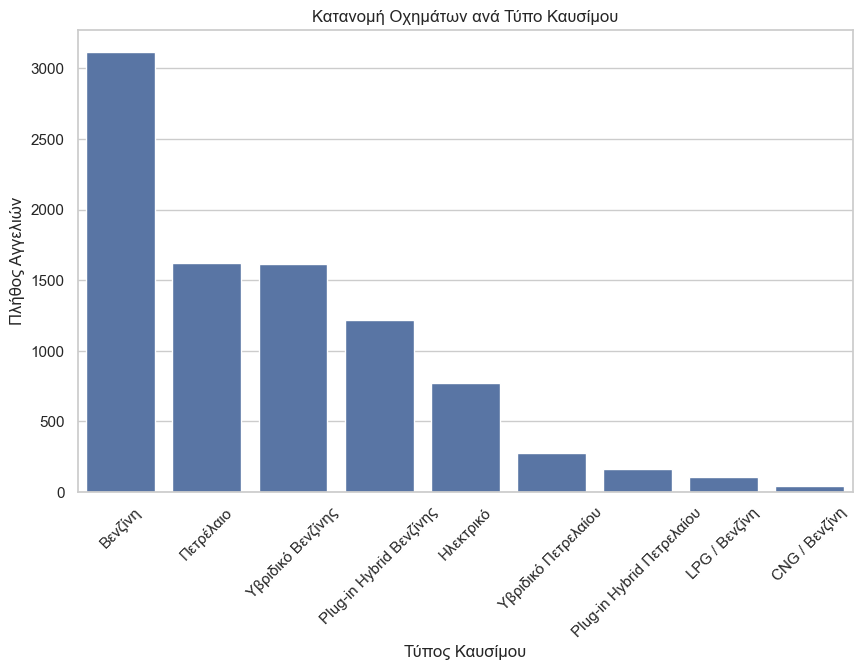

In [19]:
fuel_counts = df["Καύσιμο"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values)
plt.title("Κατανομή Οχημάτων ανά Τύπο Καυσίμου")
plt.xlabel("Τύπος Καυσίμου")
plt.ylabel("Πλήθος Αγγελιών")
plt.xticks(rotation=45)
plt.show()

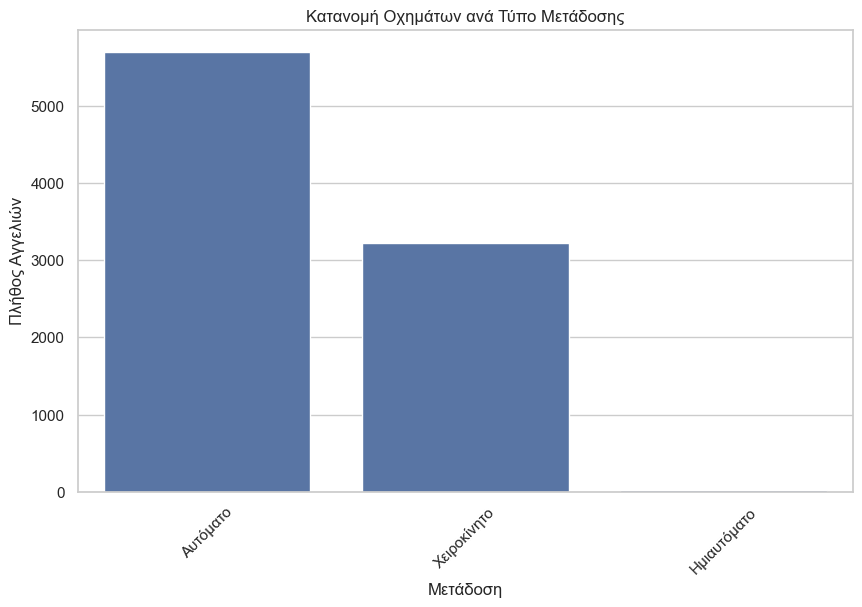

In [20]:
transmission_counts = df["Μετάδοση"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=transmission_counts.index, y=transmission_counts.values)
plt.title("Κατανομή Οχημάτων ανά Τύπο Μετάδοσης")
plt.xlabel("Μετάδοση")
plt.ylabel("Πλήθος Αγγελιών")
plt.xticks(rotation=45)
plt.show()

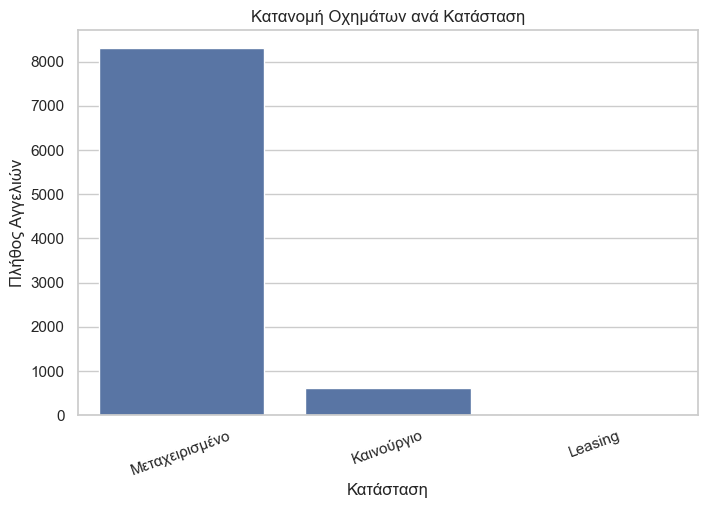

In [21]:
condition_counts = df["Κατάσταση"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=condition_counts.index, y=condition_counts.values)
plt.title("Κατανομή Οχημάτων ανά Κατάσταση")
plt.xlabel("Κατάσταση")
plt.ylabel("Πλήθος Αγγελιών")
plt.xticks(rotation=20)
plt.show()

### Σχόλιο

Η πλειονότητα των αγγελιών αφορά μεταχειρισμένα οχήματα, γεγονός που είναι συμβατό με το αντικείμενο της μελέτης, καθώς η ανάλυση εστιάζει στη δευτερογενή αγορά αυτοκινήτου.

Οι κατηγορίες `Καινούργιο` και `Leasing` εμφανίζονται σε αισθητά μικρότερο βαθμό και μπορούν να εξεταστούν περαιτέρω ως ειδικές υποομάδες.

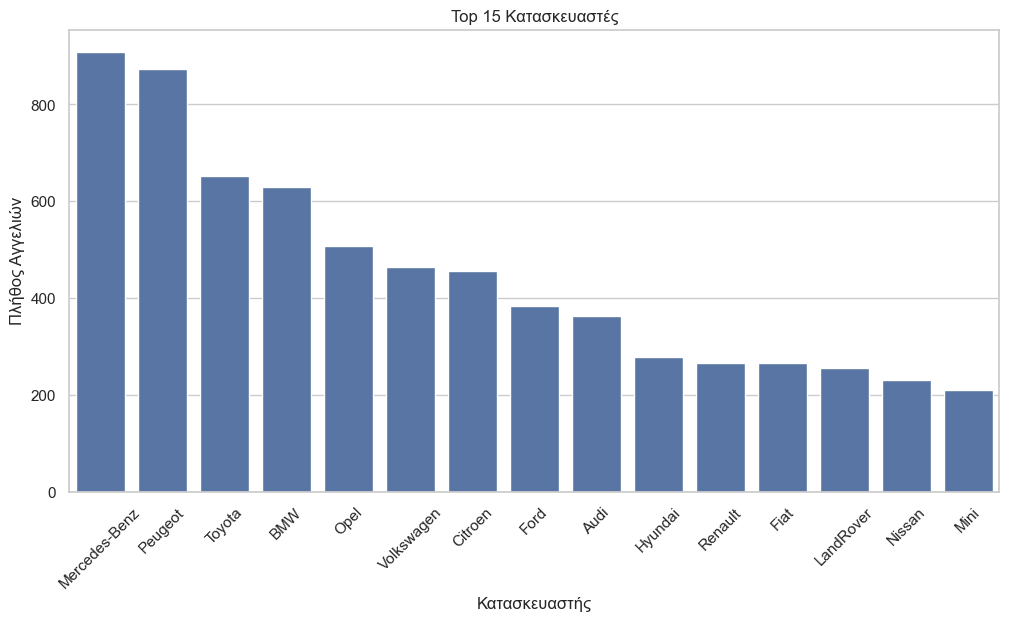

In [22]:
top_makes = df["Κατασκευαστής"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_makes.index, y=top_makes.values)
plt.title("Top 15 Κατασκευαστές")
plt.xlabel("Κατασκευαστής")
plt.ylabel("Πλήθος Αγγελιών")
plt.xticks(rotation=45)
plt.show()

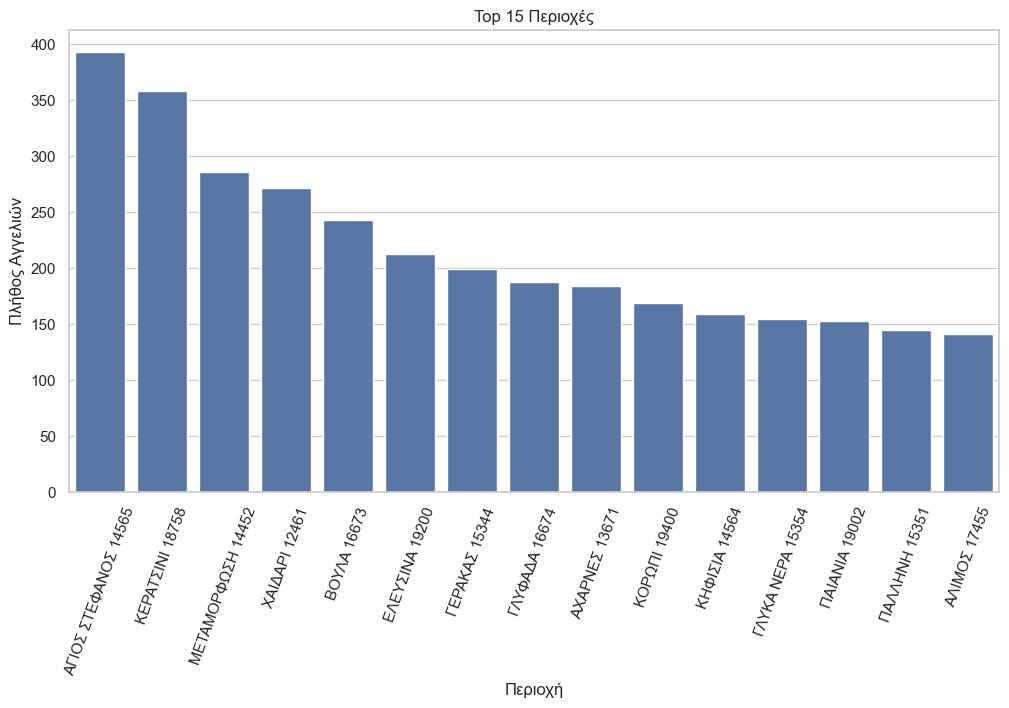

In [23]:
top_regions = df["Περιοχή"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title("Top 15 Περιοχές")
plt.xlabel("Περιοχή")
plt.ylabel("Πλήθος Αγγελιών")
plt.xticks(rotation=70)
plt.show()

## Σχέσεις της Τιμής με Βασικές Μεταβλητές  
## (Bivariate Relationships)

Στην ενότητα αυτή εξετάζονται διμεταβλητές σχέσεις μεταξύ της τιμής και βασικών χαρακτηριστικών του οχήματος.

Ο στόχος είναι να αναγνωριστούν μοτίβα που ενδέχεται να έχουν:
- ερμηνευτική αξία,
- περιγραφική σημασία,
- και προβλεπτική χρησιμότητα για το στάδιο της μοντελοποίησης.

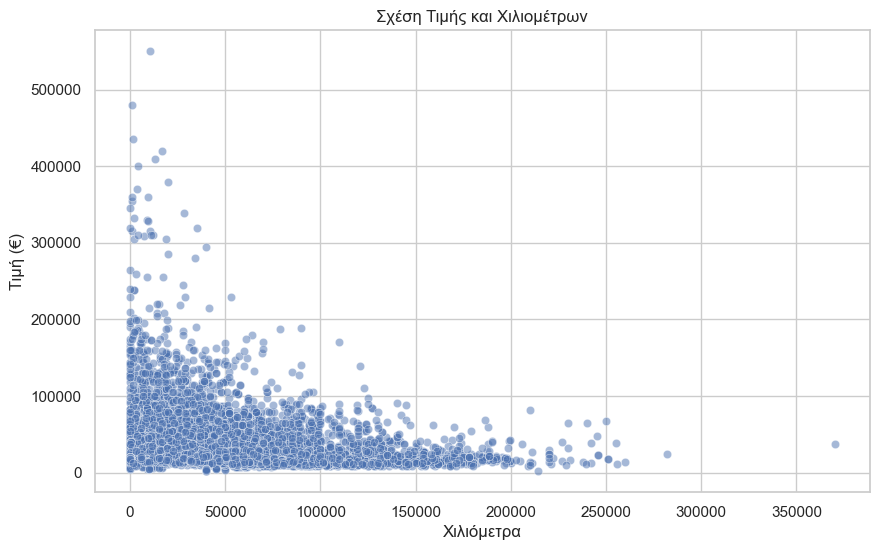

In [24]:
# Σχέση τιμής και χιλιομέτρων
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Χιλιόμετρα", y="Τιμή", alpha=0.5)
plt.title("Σχέση Τιμής και Χιλιομέτρων")
plt.xlabel("Χιλιόμετρα")
plt.ylabel("Τιμή (€)")
plt.show()

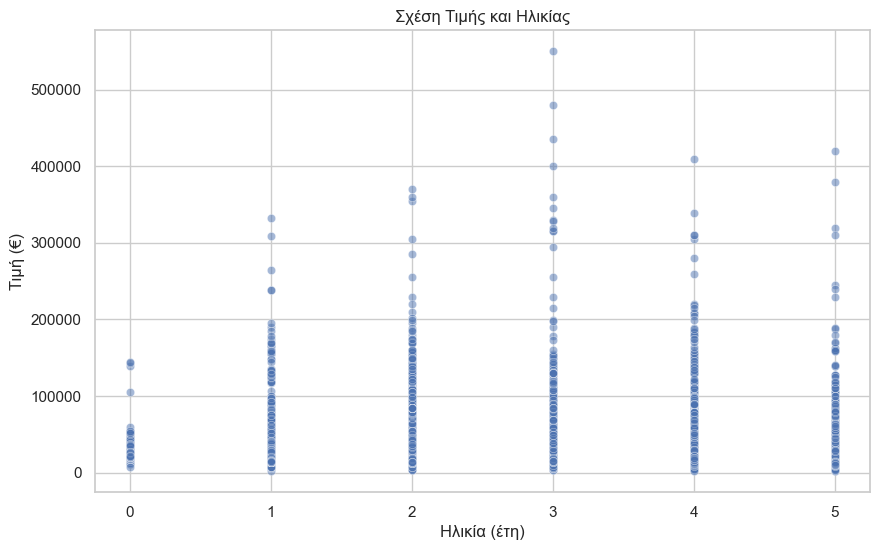

In [25]:
# Σχέση τιμής και ηλικίας
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Ηλικία", y="Τιμή", alpha=0.5)
plt.title("Σχέση Τιμής και Ηλικίας")
plt.xlabel("Ηλικία (έτη)")
plt.ylabel("Τιμή (€)")
plt.show()

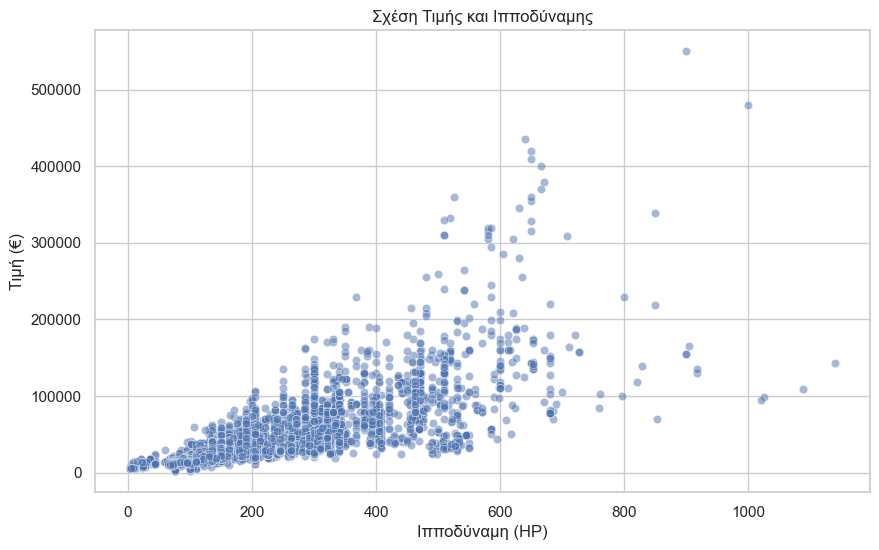

In [26]:
# Σχέση τιμής και ιπποδύναμης
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Ιπποδύναμη", y="Τιμή", alpha=0.5)
plt.title("Σχέση Τιμής και Ιπποδύναμης")
plt.xlabel("Ιπποδύναμη (HP)")
plt.ylabel("Τιμή (€)")
plt.show()

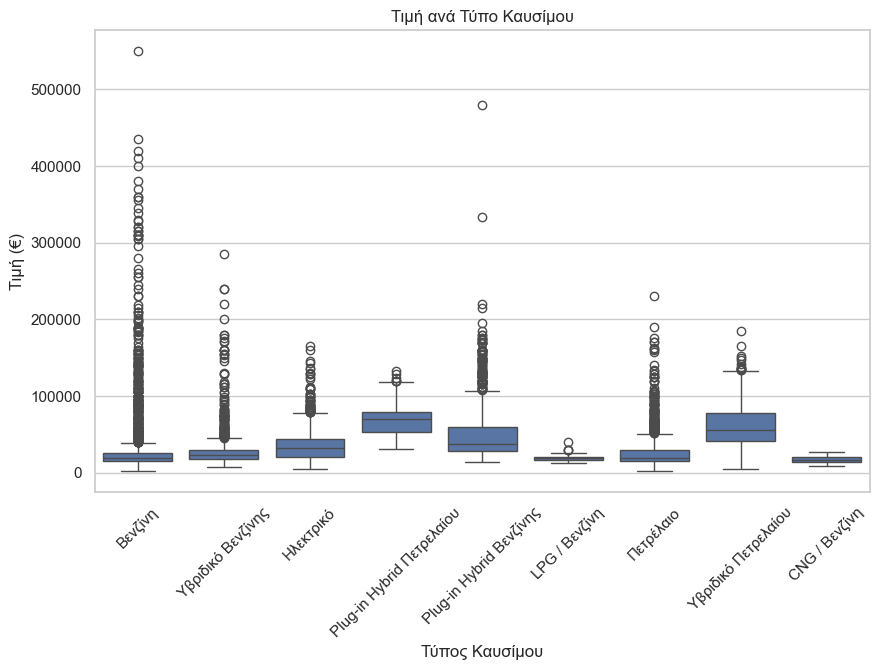

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Καύσιμο", y="Τιμή")
plt.title("Τιμή ανά Τύπο Καυσίμου")
plt.xlabel("Τύπος Καυσίμου")
plt.ylabel("Τιμή (€)")
plt.xticks(rotation=45)
plt.show()

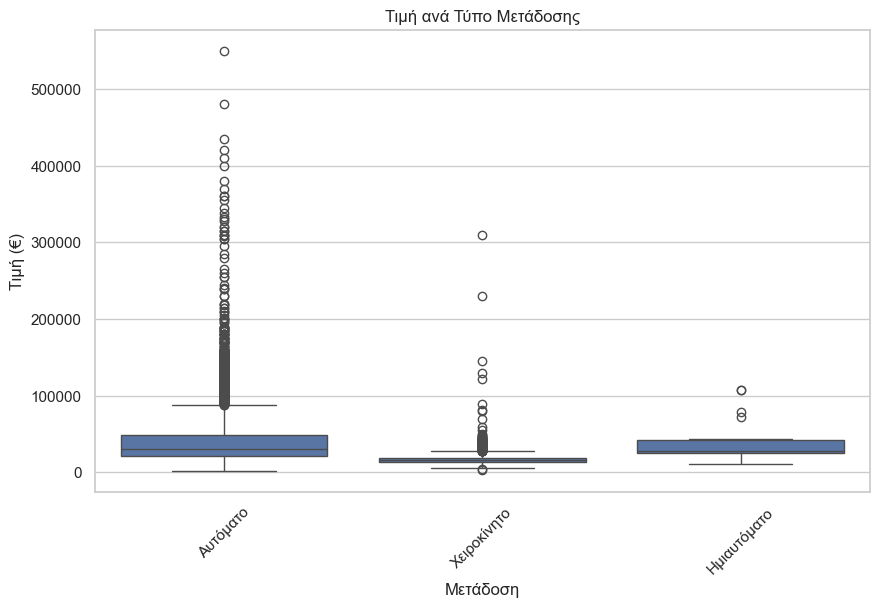

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Μετάδοση", y="Τιμή")
plt.title("Τιμή ανά Τύπο Μετάδοσης")
plt.xlabel("Μετάδοση")
plt.ylabel("Τιμή (€)")
plt.xticks(rotation=45)
plt.show()

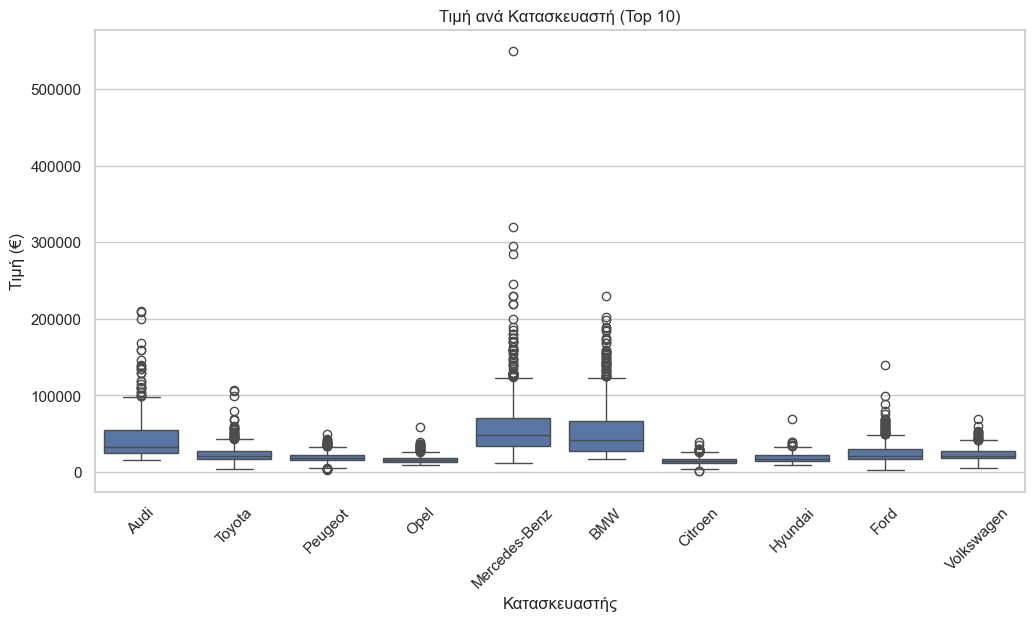

In [29]:
top_make_names = df["Κατασκευαστής"].value_counts().head(10).index
df_top_makes = df[df["Κατασκευαστής"].isin(top_make_names)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_makes, x="Κατασκευαστής", y="Τιμή")
plt.title("Τιμή ανά Κατασκευαστή (Top 10)")
plt.xlabel("Κατασκευαστής")
plt.ylabel("Τιμή (€)")
plt.xticks(rotation=45)
plt.show()

## Συσχετίσεις μεταξύ Αριθμητικών Μεταβλητών  
## (Correlation Analysis)

Η ανάλυση συσχέτισης μεταξύ των αριθμητικών μεταβλητών βοηθά στην αναγνώριση πιθανών γραμμικών σχέσεων και παρέχει μία πρώτη εικόνα για το ποια χαρακτηριστικά ενδέχεται να σχετίζονται περισσότερο με την τιμή πώλησης.

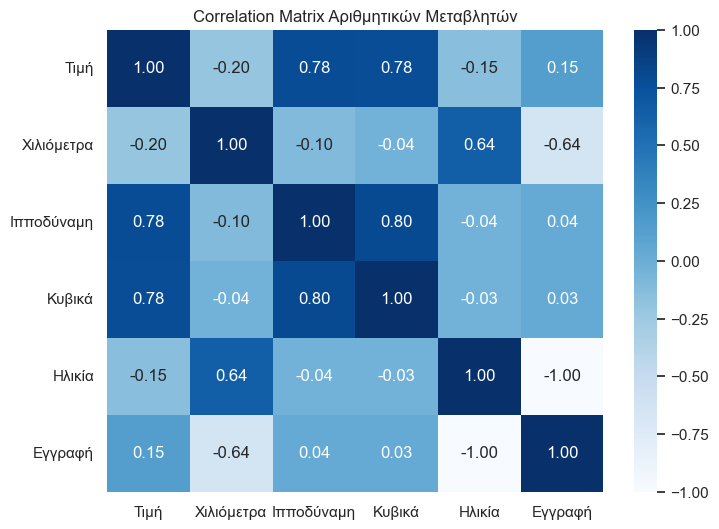

In [30]:
corr_cols = ["Τιμή", "Χιλιόμετρα", "Ιπποδύναμη", "Κυβικά", "Ηλικία", "Εγγραφή"]
corr_cols = [col for col in corr_cols if col in df.columns]

corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix Αριθμητικών Μεταβλητών")
plt.show()

## Εξέταση Ακραίων Τιμών (Outlier Review)

Οι ακραίες τιμές δεν αφαιρούνται αυτόματα σε αυτό το στάδιο.  
Αντίθετα, εξετάζονται περιγραφικά και οπτικά, ώστε να αξιολογηθεί αν πρόκειται για:

- πραγματικές αγγελίες υψηλής αξίας,
- σφάλματα καταχώρισης,
- ή ειδικές κατηγορίες οχημάτων.

Η τελική απόφαση για τυχόν **outlier handling** θα πρέπει να ληφθεί με μεθοδολογική τεκμηρίωση.

In [31]:
# Quantiles της τιμής για outlier review
df["Τιμή"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01     8,400.00
0.05    11,500.00
0.25    16,900.00
0.50    22,700.00
0.75    35,900.00
0.95    93,000.00
0.99   169,000.00
Name: Τιμή, dtype: float64

In [32]:
# Quantiles των χιλιομέτρων για outlier review
df["Χιλιόμετρα"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01         0.00
0.05         0.00
0.25    17,500.00
0.50    46,600.00
0.75    76,000.00
0.95   128,978.50
0.99   180,700.00
Name: Χιλιόμετρα, dtype: float64

In [33]:
# Προβολή των ακριβότερων οχημάτων για ποιοτικό έλεγχο
df.sort_values("Τιμή", ascending=False).head(10)[
    ["Κατασκευαστής", "Τύπος", "Τιμή", "Χιλιόμετρα", "Ιπποδύναμη", "Καύσιμο", "Κατάσταση", "Περιοχή"]
]

,Κατασκευαστής,Τύπος,Τιμή,Χιλιόμετρα,Ιπποδύναμη,Καύσιμο,Κατάσταση,Περιοχή
2954,Mercedes-Benz,G 63 AMG,"550,000.00","10,500.00",900.00,Βενζίνη,Μεταχειρισμένο,ΚΟΡΩΠΙ 19400
1719,Ferrari,SF90,"480,000.00",800.00,"1,000.00",Plug-in Hybrid Βενζίνης,Μεταχειρισμένο,ΒΟΥΛΑ 16673
2071,Lamborghini,Huracan,"435,000.00","1,700.00",640.00,Βενζίνη,Μεταχειρισμένο,ΜΕΤΑΜΟΡΦΩΣΗ 14452
8881,Lamborghini,Urus,"420,000.00","17,000.00",650.00,Βενζίνη,Μεταχειρισμένο,ΒΟΥΛΑ 16673
4446,Lamborghini,Huracan,"410,000.00","13,300.00",649.00,Βενζίνη,Μεταχειρισμένο,ΜΕΤΑΜΟΡΦΩΣΗ 14452
3368,Lamborghini,Urus,"399,980.00","4,400.00",666.00,Βενζίνη,Μεταχειρισμένο,ΓΛΥΦΑΔΑ 16674
8547,Lamborghini,Urus,"380,000.00","19,900.00",670.00,Βενζίνη,Μεταχειρισμένο,ΚΟΡΩΠΙ 19400
3019,Lamborghini,Urus,"370,000.00","3,700.00",666.00,Βενζίνη,Μεταχειρισμένο,ΒΑΡΗ 16672
2036,Porsche,911,"360,000.00","9,500.00",650.00,Βενζίνη,Μεταχειρισμένο,ΕΚΑΛΗ 14578
2959,Porsche,992,"360,000.00",800.00,525.00,Βενζίνη,Μεταχειρισμένο,ΚΟΡΩΠΙ 19400


## Κύρια Ευρήματα της Διερευνητικής Ανάλυσης

Με βάση τα προηγούμενα αποτελέσματα, μπορούν να καταγραφούν τα ακόλουθα πρώτα ευρήματα:

1. Η μεταβλητή `Τιμή` εμφανίζει σημαντική διασπορά και δεξιά ασυμμετρία (*right skewness*), γεγονός που υποδηλώνει την παρουσία ακριβότερων ή premium οχημάτων.
2. Τα `Χιλιόμετρα` φαίνεται να σχετίζονται αρνητικά με την τιμή, αν και η σχέση δεν είναι πλήρως γραμμική.
3. Η `Ηλικία` του οχήματος συνδέεται επίσης αρνητικά με την `Τιμή`, κάτι που είναι αναμενόμενο από θεωρητική άποψη.
4. Ο τύπος `Καύσιμο` διαφοροποιεί τις ζητούμενες τιμές, άρα η τεχνολογία κίνησης επηρεάζει ουσιαστικά τη δευτερογενή αγορά.
5. Παρατηρούνται εμφανείς διαφοροποιήσεις μεταξύ κατασκευαστών, γεγονός που επιβεβαιώνει τη σημασία του **brand effect**.

Τα παραπάνω ευρήματα θα αξιοποιηθούν στη συνέχεια για την επιλογή μεταβλητών και τη διαμόρφωση του μοντέλου πρόβλεψης τιμών.

## Μετάβαση στο Επόμενο Στάδιο

Το επόμενο βήμα της μελέτης είναι η χρήση του **ML-ready dataset** και η ανάπτυξη μοντέλων **price prediction**.

Η διερευνητική ανάλυση του παρόντος notebook λειτουργεί ως βάση για:
- την επιλογή μεταβλητών,
- την κατανόηση πιθανών μετασχηματισμών,
- και τη διαμόρφωση της στρατηγικής μοντελοποίησης.

In [34]:
ml_path = PROJECT_ROOT / "data" / "processed" / "ml_ready_car_data.csv"

if ml_path.exists():
    ml_df = pd.read_csv(ml_path, encoding="utf-8-sig")
    print("ML-ready dataset shape:", ml_df.shape)
    display(ml_df.head())
else:
    print("Το ml_ready_car_data.csv δεν βρέθηκε.")

ML-ready dataset shape: (8933, 12)


,Κατασκευαστής,Τύπος,Εγγραφή,Ηλικία,Καύσιμο,Μετάδοση,Κυβικά,Ιπποδύναμη,Χιλιόμετρα,Κατάσταση,Περιοχή,Τιμή
0,Audi,Q3,"2,025.00",1.00,Βενζίνη,Αυτόματο,"1,500.00",150.00,"10,500.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14561,"34,900.00"
1,Toyota,Yaris Cross,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,500.00",116.00,"10,018.00",Μεταχειρισμένο,ΝΕΑ ΙΩΝΙΑ 14235,"25,990.00"
2,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"3,000.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14562,"26,500.00"
3,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"2,900.00",Μεταχειρισμένο,ΝΕΑ ΕΡΥΘΡΑΙA 14671,"26,500.00"
4,Beev,ΒEEV-6,"2,025.00",1.00,Ηλεκτρικό,Αυτόματο,NaN,4.00,0.00,Καινούργιο,ΓΛΥΚΑ ΝΕΡΑ 15354,"10,900.00"
